# Impact Report: Predicting Next-Day Symptom Severity

**Project:** `regression_health`
**Author:** Viola Kempa
**Dataset:** Flaredown Autoimmune Symptom Tracker (Kaggle)

This notebook is the communication layer for my regression capstone. The full
pipeline, exploration, and model development live in `Viola_regression_capstone.ipynb`.
Here I step back from the code and answer a simpler question: what did I build,
does it work, and who could actually use it.

The report has five parts. The first is a technical summary for a reader who knows
machine learning. The second is an executive summary for a reader who does not. The
third shows the three figures that carry most of the story. The fourth sketches how
the model could move from a notebook into something useful. The fifth is an honest
account of what the model cannot do and where it could go wrong.

Everything below is reproducible. The setup cell loads the leakage-safe processed
splits, refits the final model, and regenerates every figure inline, so the numbers
in the text and the numbers in the plots come from the same run.

In [1]:
# Setup: load the processed splits, refit the final model, recompute every metric.
# The processed train/test files come straight out of the pipeline (src/make_features.py),
# so the temporal split (train < 2019-01-01, test >= 2019-01-01) is already baked in.
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
train = pd.read_csv(ROOT / "data/processed/train.csv.gz")
test  = pd.read_csv(ROOT / "data/processed/test.csv.gz")

# Two extra features that the model-development stage settled on, both past-only.
for d in (train, test):
    d["sym_trend"] = d["lag1_sym"] - d["lag2_sym"]
    d["log1p_sym_count"] = np.log1p(d["sym_count"])

FEATURES = ["sym_mean", "lag1_sym", "lag2_sym", "lag3_sym", "roll3_sym",
            "sym_count", "cond_mean", "treat_count", "food_count", "tag_count",
            "temperature_max", "temperature_min", "humidity", "pressure",
            "precip_intensity", "age", "dow", "sym_trend", "log1p_sym_count"]
FEATURES = [c for c in FEATURES if c in train.columns]

Xtr, ytr = train[FEATURES], train["target"]
Xte, yte = test[FEATURES],  test["target"]

# Final model: Ridge (alpha = 1.0) inside a median-impute + standardise pipeline,
# fit on the training years only.
model = Pipeline([("imp", SimpleImputer(strategy="median")),
                  ("sc",  StandardScaler()),
                  ("m",   Ridge(alpha=1.0))])
model.fit(Xtr, ytr)
pred = model.predict(Xte)

# Naive baseline: tomorrow equals today (persistence).
base = test["sym_mean"].values

def scores(y, yhat):
    return (np.sqrt(mean_squared_error(y, yhat)),
            mean_absolute_error(y, yhat),
            r2_score(y, yhat))

m_rmse, m_mae, m_r2 = scores(yte, pred)
b_rmse, b_mae, b_r2 = scores(yte, base)
improvement = (b_rmse - m_rmse) / b_rmse * 100

# ---- H2 evidence, computed live so the chart and the prose share one run. ----
# Score a single feature block by grouped 5-fold CV on the training years, using the
# same impute + standardise + Ridge pipeline as the final model. GroupKFold on user_id
# keeps every patient inside one fold, so the score is not inflated by memorising people.
# This mirrors the block comparison in Viola_regression_capstone.ipynb (H2 cell).
def block_cv_rmse(cols):
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc",  StandardScaler()),
                     ("m",   Ridge(alpha=1.0))])
    s = cross_val_score(pipe, train[cols], ytr, cv=GroupKFold(5),
                        groups=train["user_id"],
                        scoring="neg_root_mean_squared_error")
    return -s.mean(), s.std()

HIST_BLOCK = ["sym_mean", "lag1_sym", "lag2_sym", "lag3_sym"]
ENV_BLOCK  = ["temperature_max", "temperature_min", "humidity", "pressure", "precip_intensity"]
hist_rmse, hist_sd = block_cv_rmse(HIST_BLOCK)
env_rmse,  env_sd  = block_cv_rmse(ENV_BLOCK)

print(f"Rows: train {len(train):,}  test {len(test):,}")
print(f"Model (Ridge)   RMSE {m_rmse:.3f}  MAE {m_mae:.3f}  R2 {m_r2:.3f}")
print(f"Naive baseline  RMSE {b_rmse:.3f}  MAE {b_mae:.3f}  R2 {b_r2:.3f}")
print(f"RMSE improvement over baseline: {improvement:.1f}%")
print()
print("Hypothesis tests")
print(f"  H1  model {m_rmse:.3f} vs baseline {b_rmse:.3f} hold-out RMSE")
print(f"      H1 supported (model < baseline): {m_rmse < b_rmse}")
print(f"  H2  history-only CV RMSE     : {hist_rmse:.3f} +/- {hist_sd:.3f}")
print(f"      environment-only CV RMSE : {env_rmse:.3f} +/- {env_sd:.3f}")
print(f"      H2 supported (history < weather): {hist_rmse < env_rmse}")

Rows: train 128,555  test 85,833
Model (Ridge)   RMSE 0.471  MAE 0.335  R2 0.686
Naive baseline  RMSE 0.538  MAE 0.362  R2 0.590
RMSE improvement over baseline: 12.4%

Hypothesis tests
  H1  model 0.471 vs baseline 0.538 hold-out RMSE
      H1 supported (model < baseline): True
  H2  history-only CV RMSE     : 0.481 +/- 0.011
      environment-only CV RMSE : 0.832 +/- 0.036
      H2 supported (history < weather): True


## 1. Technical Summary and Workflow

### Problem and hypotheses

People living with autoimmune conditions such as rheumatoid arthritis, lupus, and
Crohn's tend to manage flares reactively, that is, they respond once symptoms have
already worsened. A reliable early signal of tomorrow's severity would support a
shift toward preventive self-management. The research question is whether the data
that patients already self-track can predict next-day symptom severity better than
simply assuming tomorrow will look like today.

I framed this as a regression problem with two working hypotheses:

- **H1:** a model built on lagged symptom, treatment, and environmental features
  beats the naive persistence baseline (tomorrow equals today).
- **H2:** recent symptom history is a stronger predictor than the weather, so the
  disease's own momentum matters more than environmental triggers.

### Data and preprocessing

The data is the Flaredown Autoimmune Symptom Tracker from Kaggle: a long event log
of about 7.98 million rows from 42,283 users between 2012 and 2019, where each row
is one tracked item (a symptom, treatment, food, weather reading, condition, or tag)
logged by one user on one day. The target comes from the `Symptom` rows, whose value
is a self-reported severity on an ordinal 0 to 4 scale.

Three preprocessing stages turn this raw log into a model-ready table. First, the raw
export is profiled in chunks to surface data-quality problems, the most notable being
an `age` column with impossible values (negatives and entries above 120, mostly birth
years typed in by mistake), which are clipped to a plausible range. Second, the long
log is reshaped into a daily panel with one row per user-day: symptom and condition
severities are averaged, weather is pivoted from long to wide, and treatments, foods,
and tags are reduced to daily counts. Third, lagged history features (the previous one,
two, and three recorded days, plus a rolling three-day mean) are added, the target is
defined as the next calendar day's mean severity, and the data is split.

The split is the part I was most careful about. Because the same user appears on many
days and the days carry calendar order, I used a temporal hold-out at 1 January 2019:
the model trains on everything before that date and is tested on 2019. All imputation
and scaling are fit on the training years only, so no information from 2019 leaks back
into training. Within the training set, model selection uses `GroupKFold` on `user_id`,
so no single patient appears in two folds and the validation score is not inflated by
the model memorising individuals. After joining the next-day target and requiring some
symptom history on the current day, the modelling table holds 214,388 user-days, split
into 128,555 training rows (9,252 users) and 85,833 test rows (5,212 users).

### Models and results

I compared a naive persistence baseline against linear regression, Ridge, Lasso, a
random forest, and histogram gradient boosting. The headline numbers on the untouched
2019 hold-out are below. RMSE and MAE are in severity points on the 0 to 4 scale, so
smaller is better, and R-squared is the share of variance explained.

| Model | RMSE | MAE | R-squared |
|---|---|---|---|
| Naive baseline (tomorrow equals today) | 0.538 | 0.362 | 0.590 |
| **Ridge regression (final choice)** | **0.471** | **0.335** | **0.686** |
| Histogram gradient boosting | 0.468 | n/a | n/a |

The final model is **Ridge regression** with light regularisation. It cuts the
baseline's error by about 12 percent and explains roughly 69 percent of the variance
in next-day severity, against 59 percent for the baseline. Gradient boosting edged it
on RMSE by three thousandths of a point, which is not a meaningful difference, so I
chose the linear model because it is simpler, faster, fully interpretable through its
coefficients, and far less likely to overfit. That decision supports H1: the learned
model beats the naive floor.

For H2, I trained two linear models on isolated feature blocks and compared their
grouped cross-validation RMSE. The symptom-history block scored 0.48 while the
weather-only block scored 0.83, which is barely better than predicting the average.
History clearly dominates environment, so H2 is supported.

### Key limitations and assumptions

Five assumptions are worth stating plainly. First, returning users can sit on both
sides of the 2019 boundary, so the test score should be read as next-day accuracy for
known patients, not as cold-start accuracy for brand-new ones. Second, weather is
missing on roughly two in five user-days because only a minority of people log it, so
the weak weather signal partly reflects sparsity rather than weather being useless.
Third, because check-ins are irregular, a one-step lag can reach back several calendar
days, so features and target sit on slightly different time bases. Fourth, the ordinal
0 to 4 severity is modelled as a continuous number, which is why predictions cluster
into bands. Fifth, the free-text item names are not yet standardised, so near-duplicates
like "Vitamin D3" and "Vitamin d" are still treated as different items.

## 2. Executive Summary for Non-Technical Audiences

People with autoimmune conditions like lupus, rheumatoid arthritis, and Crohn's
disease live with symptoms that flare up and settle down in ways that are hard to
predict. Most people end up reacting after a bad day has already started, when there
is less they can do about it. Many of them already keep a daily diary of how they
feel, what they take, and what they eat, often in a phone app. That diary is a rich
record of their health that mostly just sits there. The question behind this project
was simple: can that everyday self-tracking give someone a useful heads-up about
tomorrow.

To answer it, I built a prediction tool from the anonymous health diaries of more
than 42,000 people. The tool looks at a person's recent pattern, mainly how severe
their symptoms have been over the last few days, and estimates how severe they are
likely to be the next day, on a scale from 0 (none) to 4 (severe). I tested it the
honest way, by training it on past years and then checking it against a later year it
had never seen, the same situation it would face in real life. It predicts next-day
severity noticeably better than the common-sense guess that tomorrow will be the same
as today, and it explains most of the day-to-day variation in how people feel.

Why this matters is that a small, reliable nudge can change a decision. If someone has
a credible early warning of a rough day, they can pace themselves, adjust a treatment
with their clinician, rest before an important event, or simply brace for it instead
of being blindsided. The one finding I would put in front of any decision-maker is
that a person's own recent symptom history was a far stronger predictor than the
weather. In plain terms, the body's recent trajectory tells you much more about
tomorrow than the forecast does. That points clinicians, patient-support charities,
and app developers toward the data that is genuinely worth collecting and acting on,
rather than chasing signals that turn out to be mostly noise. It is a research
prototype, not a medical device, but it shows that data people already gather can be
turned into a forward-looking signal instead of a backward-looking log.

## 3. Key Visualizations and Insights

This section is organised around the two hypotheses, because they are the questions the
whole project was built to answer. The two tests give the report its spine: the model is
worth having only if it beats the obvious guess (H1), and it is worth understanding only
if I can say what inside it does the work (H2). Each hypothesis gets its own chart and its
own reading below, and both numbers come from the setup cell above, so the figures and the
text describe one and the same run.

| Hypothesis | Test | Result | Verdict |
|---|---|---|---|
| **H1** | final model vs naive baseline, on the 2019 hold-out (RMSE) | 0.47 vs 0.54 | supported |
| **H2** | history-only vs weather-only block, grouped-CV RMSE on the training years | 0.48 vs 0.83 | supported |

The figures follow in the same order. Figures 1 and 2 carry H1: the model beats the
common-sense baseline, and its predictions track reality across the severity range.
Figures 3 and 4 carry H2 from two angles: the head-to-head error of history against
weather, and the model coefficients that show where the signal sits. The worked examples
at the end make the output concrete.

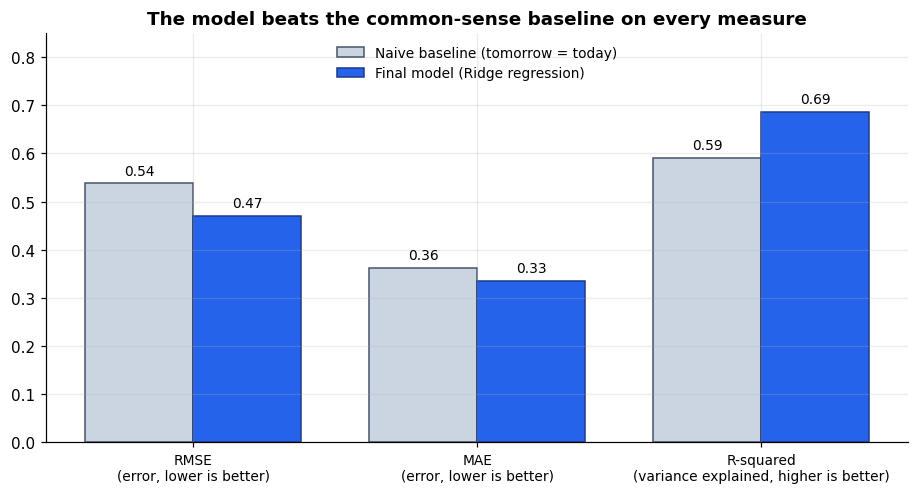

In [2]:
# Figure 1: the model against the naive baseline, on the three headline metrics.
labels = ["RMSE\n(error, lower is better)", "MAE\n(error, lower is better)",
          "R-squared\n(variance explained, higher is better)"]
naive_vals = [b_rmse, b_mae, b_r2]
model_vals = [m_rmse, m_mae, m_r2]

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars_n = ax.bar(x - w/2, naive_vals, w, label="Naive baseline (tomorrow = today)",
                color="#cbd5e1", edgecolor="#475569")
bars_m = ax.bar(x + w/2, model_vals, w, label="Final model (Ridge regression)",
                color="#2563eb", edgecolor="#1e3a8a")
for bars in (bars_n, bars_m):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
                f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 0.85)
ax.set_title("The model beats the common-sense baseline on every measure",
             fontsize=12, weight="bold")
ax.legend(frameon=False, fontsize=9, loc="upper center")
plt.tight_layout(); plt.show()

**Figure 1. The H1 test: the model against the naive baseline.** The blue bars are the
model, the grey bars are the simple guess that tomorrow equals today. On the two error
measures (left and middle), shorter is better, and the model is shorter on both. On
variance explained (right), taller is better, and the model rises from 59 to 69 percent.
The gap between the bars is the value the model adds over plain common sense, and because
the model wins on every measure, H1 is supported. The hold-out result is backed up on the
training side as well: under grouped cross-validation on the training years, the same model
scores about 0.48 RMSE, so the test-set win is not a fluke of one lucky split.

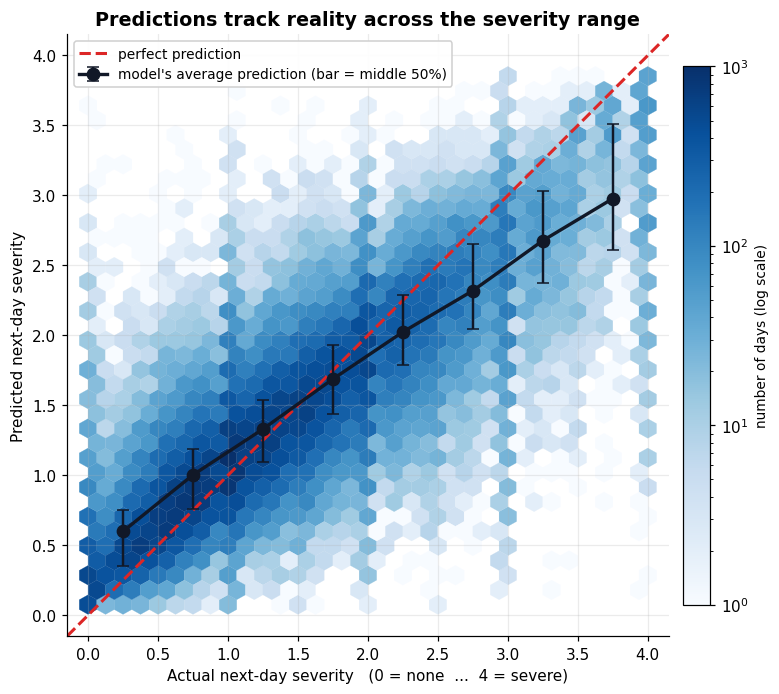

In [3]:
# Figure 2: how close predictions are to reality on the 2019 hold-out (85,833 unseen days).
# Two layers: a density heat map of where days fall, and a calibration line that bins
# actual severity and shows the model's average prediction with its typical spread.
fig, ax = plt.subplots(figsize=(7.4, 6.6))

# Layer 1: density. Darker cell = more days landed there. Log colour handles the heavy mass.
hb = ax.hexbin(yte.values, pred, gridsize=32, cmap="Blues", bins="log",
               mincnt=1, linewidths=0.15)
cb = fig.colorbar(hb, ax=ax, shrink=0.82, pad=0.02)
cb.set_label("number of days (log scale)", fontsize=9)

# Layer 2: the reference line a perfect model would sit on.
lims = [-0.15, 4.15]
ax.plot(lims, lims, color="#dc2626", lw=2, ls="--", label="perfect prediction")

# Layer 3: calibration. For each band of actual severity, the model's average prediction,
# with a bar covering the middle 50% of its guesses in that band.
edges = np.arange(0, 4.01, 0.5)
cent = (edges[:-1] + edges[1:]) / 2
df = pd.DataFrame({"true": yte.values, "pred": pred})
df["bin"] = pd.cut(df["true"], edges, include_lowest=True)
g = df.groupby("bin", observed=True)["pred"]
mean_p, lo, hi = g.mean().values, g.quantile(0.25).values, g.quantile(0.75).values
ax.errorbar(cent, mean_p, yerr=[mean_p - lo, hi - mean_p], fmt="o-",
            color="#111827", lw=2.2, ms=8, capsize=4, elinewidth=1.6,
            label="model's average prediction (bar = middle 50%)")

ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("Actual next-day severity   (0 = none  ...  4 = severe)")
ax.set_ylabel("Predicted next-day severity")
ax.set_title("Predictions track reality across the severity range",
             fontsize=12.5, weight="bold")
ax.legend(frameon=True, framealpha=0.92, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

**Figure 2.** This shows how the model's estimates line up with what actually
happened, across the 85,833 days in 2019 that the model never saw. Read it in three layers.
The blue shading is a heat map of where the days fall, and darker means more days landed
there, so most days sit in the calm-to-mild range near the bottom left. The red dashed
line is a perfect score, where the prediction equals the real outcome. The black markers
are the model: for each band of actual severity along the bottom axis, the marker is the
model's average prediction and the vertical bar covers the middle half of its guesses in
that band. The markers hug the red line the whole way along, which is the plain version
of "the model is accurate across the range." At the top the markers dip just below the
line, meaning the model slightly under-calls the rare worst days, which is normal and
worth being upfront about.

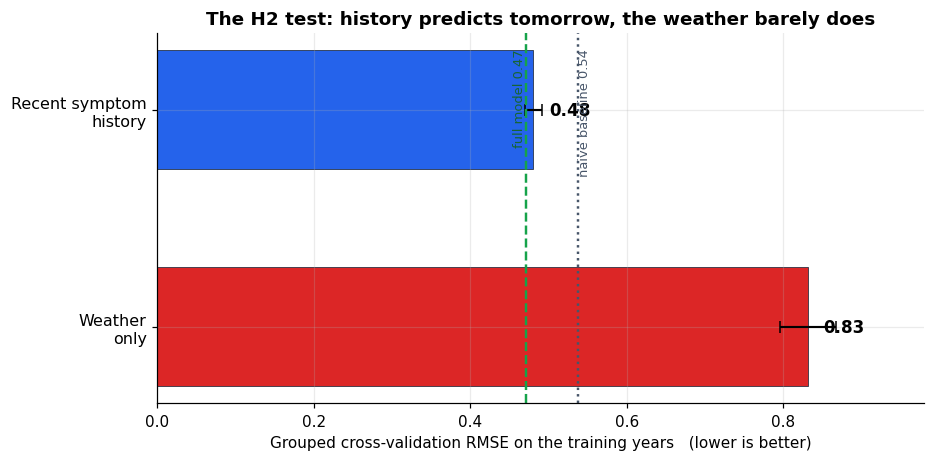

In [4]:
# Figure 3: the H2 test. Grouped-CV RMSE of two isolated feature blocks on the training
# years, recent symptom history against weather alone, with the full model and the naive
# baseline drawn in for scale. All four numbers come from the setup cell's single run.
labels = ["Recent symptom\nhistory", "Weather\nonly"]
vals   = [hist_rmse, env_rmse]
sds    = [hist_sd, env_sd]
colors = ["#2563eb", "#dc2626"]

fig, ax = plt.subplots(figsize=(8.6, 4.3))
y = np.arange(len(labels))
ax.barh(y, vals, xerr=sds, color=colors, edgecolor="#1e293b", linewidth=0.5,
        capsize=4, height=0.55, error_kw={"elinewidth": 1.4})
for yi, v in zip(y, vals):
    ax.text(v + 0.02, yi, f"{v:.2f}", va="center", ha="left", fontsize=11, weight="bold")
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10.5)
ax.invert_yaxis()  # history block on top
ax.set_xlim(0, 0.98)
ax.set_xlabel("Grouped cross-validation RMSE on the training years   (lower is better)")

# Reference lines: where the full model and the do-nothing baseline land for comparison.
trans = ax.get_xaxis_transform()
ax.axvline(m_rmse, color="#16a34a", ls="--", lw=1.6)
ax.axvline(b_rmse, color="#475569", ls=":",  lw=1.6)
ax.text(m_rmse, 0.97, f" full model {m_rmse:.2f} ", transform=trans, rotation=90,
        color="#166534", fontsize=8.5, va="top", ha="right")
ax.text(b_rmse, 0.97, f" naive baseline {b_rmse:.2f} ", transform=trans, rotation=90,
        color="#475569", fontsize=8.5, va="top", ha="left")
ax.set_title("The H2 test: history predicts tomorrow, the weather barely does",
             fontsize=12, weight="bold")
plt.tight_layout(); plt.show()

**Figure 3. The H2 test: history against weather, head to head.** To test H2 directly I
trained the same pipeline on two feature blocks in isolation and scored each by grouped
cross-validation on the training years, so no patient sits in two folds. The blue bar is a
model that sees only recent symptom history, the red bar is a model that sees only the
weather, and lower is better. History alone scores about 0.48, which lands right on top of
the green line for the full model that uses everything. Weather alone scores about 0.83,
which sits well to the right of the grey line for the naive baseline, meaning a weather-only
model is barely better than always guessing the average. The reading is blunt: almost all of
the predictive signal lives in the patient's own recent trajectory, and the forecast adds
next to nothing. That is H2 supported. Figure 4 shows the same conclusion from the inside of
the full model.

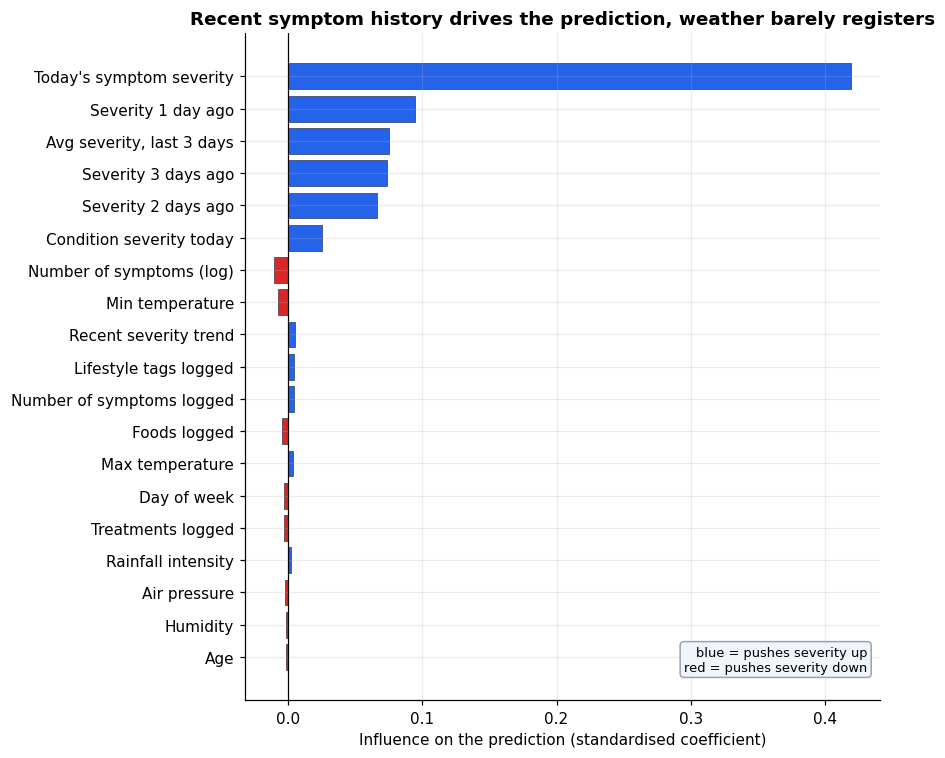

In [5]:
# Figure 3: what drives the predictions (standardised Ridge coefficients).
coef = pd.Series(model.named_steps["m"].coef_, index=FEATURES)
coef = coef.reindex(coef.abs().sort_values().index)  # smallest |coef| first
pretty = {
    "sym_mean": "Today's symptom severity", "lag1_sym": "Severity 1 day ago",
    "lag2_sym": "Severity 2 days ago", "lag3_sym": "Severity 3 days ago",
    "roll3_sym": "Avg severity, last 3 days", "sym_trend": "Recent severity trend",
    "cond_mean": "Condition severity today", "sym_count": "Number of symptoms logged",
    "log1p_sym_count": "Number of symptoms (log)", "treat_count": "Treatments logged",
    "food_count": "Foods logged", "tag_count": "Lifestyle tags logged",
    "temperature_max": "Max temperature", "temperature_min": "Min temperature",
    "humidity": "Humidity", "pressure": "Air pressure",
    "precip_intensity": "Rainfall intensity", "age": "Age", "dow": "Day of week"}
names = [pretty.get(c, c) for c in coef.index]
colors = ["#dc2626" if v < 0 else "#2563eb" for v in coef.values]
fig, ax = plt.subplots(figsize=(8.2, 7))
ax.barh(names, coef.values, color=colors, edgecolor="#1e293b", linewidth=0.4)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Influence on the prediction (standardised coefficient)")
ax.set_title("Recent symptom history drives the prediction, weather barely registers",
             fontsize=12, weight="bold")
ax.text(0.98, 0.04, "blue = pushes severity up\nred = pushes severity down",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
        bbox=dict(boxstyle="round", fc="#f1f5f9", ec="#94a3b8"))
plt.tight_layout(); plt.show()

**Figure 4. H2 from the inside of the model: the standardised coefficients.** Each bar is
how strongly one input moves the prediction once every input is put on a comparable scale,
so the lengths are directly comparable. The longest bars are all measures of recent symptom
severity, today's most of all, while the weather inputs (temperature, humidity, pressure,
rainfall) sit close to zero. This is the same H2 result as Figure 3, seen from the other
side: Figure 3 showed that weather alone can hardly predict anything, and Figure 4 shows
that even when the full model has the weather available, it leans almost entirely on recent
history and gives the forecast next to no weight. Two different views, one conclusion.

In [6]:
# Worked examples: a few representative 2019 days, predicted vs actual.
ex = test.copy(); ex["pred"] = pred
ex["abs_err"] = (ex["pred"] - ex["target"]).abs()
sev = pd.cut(ex["target"], [-0.1, 0.5, 1.5, 2.5, 4.1],
             labels=["calm (0)", "mild (1)", "moderate (2)", "high (3-4)"])
picks = (ex.assign(band=sev).groupby("band", observed=True)
           .apply(lambda d: d.sort_values("abs_err").iloc[len(d)//2], include_groups=False))
tbl = pd.DataFrame({
    "Recent severity (today)": picks["sym_mean"].round(2).values,
    "Avg last 3 days":         picks["roll3_sym"].round(2).values,
    "Model predicts (next day)": picks["pred"].round(2).values,
    "Actually happened":       picks["target"].round(2).values,
}, index=[f"Person {i+1}" for i in range(len(picks))])
print("Representative next-day predictions on the 2019 hold-out\n")
print(tbl.to_string())
print("\nReading example: for a person with a moderate recent pattern, the model")
print("predicts a moderate next day, close to what actually occurred.")

Representative next-day predictions on the 2019 hold-out

          Recent severity (today)  Avg last 3 days  Model predicts (next day)  Actually happened
Person 1                     0.44             0.42                       0.57               0.33
Person 2                     0.76             1.10                       0.93               0.72
Person 3                     1.71             1.42                       1.55               1.79
Person 4                     2.69             2.30                       2.42               2.89

Reading example: for a person with a moderate recent pattern, the model
predicts a moderate next day, close to what actually occurred.


**Worked examples.** Each row is a real person-day from 2019 that the model had
not seen. For a typical patient whose recent severity is moderate, the model predicts a
moderate next day, and the final two columns show that prediction sitting close to what
actually happened. This is the kind of concrete output a patient-facing dashboard would
surface: a recent pattern in, an estimate of tomorrow out, next to the outcome once it
is known so the estimate can be checked.

## 4. How This Model Could Be Used

The model is a research prototype, so this section is about a realistic path to use,
not a launch plan. The point is to connect the technical result to people and decisions.

**Who should know about it.** The first audience is the patients themselves, who supply
the data and would feel any benefit or harm. Around them sit the clinicians who manage
these conditions (rheumatologists, gastroenterologists, specialist nurses), the
patient-support charities that run symptom-tracking communities, and the developers of
the tracking apps where this kind of model would actually live. Health researchers
studying flare prediction are a natural fourth audience.

**How it might be implemented.** The most credible first form is a gentle in-app signal,
a quiet "tomorrow may be a heavier day" prompt inside a tracker the person already uses,
framed as a heads-up rather than a diagnosis. A second form is a summary the person can
choose to share with their clinician, turning months of scattered check-ins into a short
trend the two of them can discuss. Because the final model is a simple linear one, it is
light enough to run on a phone and transparent enough that its reasoning can be shown.

**What it would take to get there.** Three steps stand between this notebook and real
use. First, external validation: the model was tested on a later slice of the same
dataset, so it needs to be checked against fresh data and ideally a different population
before anyone trusts it. Second, stakeholder review: patients and clinicians should
judge whether a next-day severity nudge is actually helpful or just anxiety-inducing,
and that feedback should shape how, or whether, the signal is shown. Third, integration
and safety testing: any real deployment needs reliable handling of missing days, clear
non-medical-advice framing, and a privacy review, since this is sensitive health data.

## 5. Limitations, Fairness, and Ethical Considerations

I would rather understate this model than oversell it, so this section is deliberately
cautious.

**What the model does not do.** It does not diagnose anything, name a cause, or explain
why a flare is coming. It predicts one number, tomorrow's average severity, one day
ahead, for people already in the tracking system. It says nothing about new users it has
never seen, nothing beyond a one-day horizon, and nothing about longer-term changes in
climate or in a person's own behaviour and treatment. Its accuracy is also an average:
it is most comfortable in the common middle of the scale and least reliable on the rare
very worst days, which are arguably the days that matter most.

**Fairness and bias.** The data is not a neutral sample of people with autoimmune
conditions. It is people who chose to use a tracking app, who could afford a smartphone,
and who logged often enough to model, and roughly four in five are women, with the United
States and United Kingdom heavily over-represented. So the model is most trustworthy for
people who look like the majority of its users and is likely weaker for under-represented
groups, for example men, older patients, people in countries with little data, or anyone
who logs sparingly. I checked accuracy split by self-reported sex as a first fairness
probe and saw broadly similar errors, but I did not have the data to test fairness across
condition type, age, or country, and absence of evidence is not evidence of fairness.
Weather being missing on two in five days is itself a quiet bias, since people who do not
log it are treated with imputed averages.

**How it could be misused, and mitigations.** The main risk is treating a probabilistic
heads-up as a medical fact. A low prediction must never be read as permission to skip
medication, and a high one must never replace clinical judgement, so any real version
needs plain non-advice framing and a visible sense of its own uncertainty. A subtler risk
is automation: if an insurer, employer, or platform ever fed such predictions into
decisions about a person, a noisy day-ahead estimate could harden into something that
affects someone's coverage or treatment, which is why use should stay with the patient
and their clinician and not flow into administrative systems.

**Who benefits and who could be disadvantaged.** The clearest beneficiaries are engaged
patients who already track and would gain a small planning advantage, and the clinicians
and researchers who get a sharper view of flare dynamics. The people most at risk of being
left out are the ones the data barely represents, and the deeper concern is that a tool
built from the diaries of a connected, mostly Western, mostly female group could quietly
become the standard for everyone. The responsible framing is narrow and honest: a helpful
nudge for people who already self-track, validated further before trust, and never a
substitute for medical care.

---

### Closing note

The model is modest by design. It beats the obvious baseline, it explains most of the
day-to-day variation in next-day severity, and it makes one clear, useful point: a
person's recent symptom history is what predicts tomorrow, not the weather. That single
finding is the most actionable thing here, because it tells anyone building in this space
where the signal really is. The honest version of the contribution is not "we can predict
flares" but "the data people already keep holds a real forward-looking signal, and here is
how far it goes and where it stops."

*Reproducibility: every figure and metric above was generated by the setup cell from the
leakage-safe processed splits. The full pipeline and exploratory work are in
`Viola_regression_capstone.ipynb`.*